# CAMELS-GB v2 — the field reference

Every column in every file: what it means, how it was measured, its units, its
source, and what the data on disk actually contains.

**Two independent halves, kept visibly separate.**

| | Where it comes from | Can it be wrong? |
|---|---|---|
| *description, unit, source* | quoted verbatim from the publisher's supporting-information document | only if the publisher is wrong — and §12 finds one case |
| *dtype, missing %, range, levels* | measured from the files in `data/` at run time | no — it is the data |

The documented half lives in [`reference/camels_gb_v2_data_dictionary.csv`](../reference/camels_gb_v2_data_dictionary.csv),
extracted from `camels_gb_v2_eidc_supp_info.docx` in the dataset's *Supporting
documents* package (`https://data-package.ceh.ac.uk/sd/9a46d428-958f-4ac1-86eb-94eee70c0955.zip`).
It covers **263 fields — every column in all twelve file types, with none left
undocumented and none documented that does not exist.**

Citation: Coxon, G. *et al.* (2025). *Catchment boundaries, daily and sub-daily
hydrometeorological time series, groundwater level time series and attributes for
671 catchments in Great Britain (CAMELS-GB v2)*. NERC EDS EIDC.
[doi:10.5285/9a46d428-958f-4ac1-86eb-94eee70c0955](https://doi.org/10.5285/9a46d428-958f-4ac1-86eb-94eee70c0955)
Open Government Licence.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "data" / "Catchment_Attributes").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA, ATTR = ROOT / "data", ROOT / "data" / "Catchment_Attributes"
TS = ROOT / "data" / "Catchment_Timeseries"
DAILY  = TS / "hydro-meteorological" / "daily"
HOURLY = TS / "hydro-meteorological" / "hourly"
GW     = TS / "groundwater"

SURFACE, INK, INK_2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "font.family": "DejaVu Sans", "font.size": 10, "text.color": INK,
    "axes.labelcolor": INK_2, "axes.titlecolor": INK, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True,
    "axes.axisbelow": True, "legend.frameon": False,
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

DICT = pd.read_csv(ROOT / "reference" / "camels_gb_v2_data_dictionary.csv")
print(f"data dictionary: {len(DICT)} documented fields across "
      f"{DICT['scope'].nunique()} scopes")
print(DICT["scope"].value_counts().to_string())

data dictionary: 263 documented fields across 12 scopes
scope
landcover            65
soil                 49
hydrometry           33
humaninfluence       28
groundwaterwell      15
hydrologic           15
topographic          15
climatic             12
timeseries_daily     11
hydrogeology         10
timeseries_hourly     8
timeseries_gw         2


## How to read the tables below

Each section prints one table per file. The left columns are **measured now**;
the right columns are **quoted from the publisher**.

- `dtype` — what pandas infers on read
- `missing` — count and percentage of NaN
- `values` — observed min … max for numbers, or the actual levels for text
- `unit` / `description` / `source` — the publisher's own words

In [2]:
def read_attr(name):
    # camels_gb_v2_hydrometry_attributes.csv has two unquoted commas inside its
    # final free-text column, which stops the C parser dead. Fold them back.
    path = ATTR / f"camels_gb_v2_{name}_attributes.csv"
    try:
        return pd.read_csv(path, na_values=["NaN"])
    except pd.errors.ParserError:
        ncol = len(pd.read_csv(path, nrows=0).columns)
        return pd.read_csv(path, engine="python", na_values=["NaN"],
                           on_bad_lines=lambda f: f[:ncol - 1] + [",".join(f[ncol - 1:])])

def describe_values(s, max_levels=5):
    if pd.api.types.is_bool_dtype(s):
        vc = s.value_counts()
        return "  ·  ".join(f"{k}: {v}" for k, v in vc.items())
    if pd.api.types.is_numeric_dtype(s):
        lo, hi = s.min(), s.max()
        whole = s.dropna().mod(1).eq(0).all() if s.notna().any() else False
        body = f"{lo:,.4g} … {hi:,.4g}"
        return body + ("  (whole numbers)" if whole and not s.dropna().empty else "")
    if pd.api.types.is_datetime64_any_dtype(s):
        return f"{s.min()} … {s.max()}"
    u = s.dropna().unique()
    shown = "  ·  ".join(str(x)[:34] for x in u[:max_levels])
    return shown + (f"   (+{len(u) - max_levels} more)" if len(u) > max_levels else "")

def fields(df, scope, order=None):
    """Join a frame's measured reality to its documented meaning."""
    doc = DICT[DICT.scope == scope].set_index("column")
    rows = []
    for c in (order or df.columns):
        s, m = df[c], (doc.loc[c] if c in doc.index else None)
        rows.append({
            "column": c,
            "dtype": str(s.dtype),
            "missing": ("—" if s.notna().all()
                        else f"{int(s.isna().sum())}  ({s.isna().mean() * 100:.1f}%)"),
            "values": describe_values(s),
            "unit": (m["unit"] if m is not None else "?"),
            "description": (m["description"] if m is not None else "NOT DOCUMENTED"),
        })
    return pd.DataFrame(rows)

def show(tbl, wrap=("description", "values")):
    return (tbl.style.hide(axis="index")
            .set_properties(**{"font-size": "11px", "vertical-align": "top"})
            .set_properties(subset=list(wrap),
                            **{"white-space": "normal", "text-align": "left"})
            .set_table_styles([
                {"selector": "th", "props": [("text-align", "left"),
                                             ("font-size", "11px")]},
                {"selector": "td", "props": [("padding", "3px 8px")]}]))

def sources(scope):
    s = (DICT[(DICT.scope == scope) & DICT.source.notna() & (DICT.source != "-")]
         ["source"].unique())
    for x in s:
        print("source:", x)

## 1. The nine attribute files at a glance

All nine key on `gauge_id` (the NRFA gauging-station number) except the
groundwater well table, which keys on `gw_well_id`.

In [3]:
ATTR_FILES = ["topographic", "climatic", "hydrologic", "hydrogeology", "landcover",
              "soil", "hydrometry", "humaninfluence", "groundwaterwell"]
frames = {n: read_attr(n) for n in ATTR_FILES}

overview = pd.DataFrame([{
    "file": f"camels_gb_v2_{n}_attributes.csv",
    "rows": len(frames[n]),
    "columns": frames[n].shape[1],
    "documented": int((DICT.scope == n).sum()),
    "numeric": int(frames[n].select_dtypes("number").shape[1]),
    "text/bool": int(frames[n].shape[1] - frames[n].select_dtypes("number").shape[1]),
    "cells missing %": round(100 * frames[n].isna().to_numpy().mean(), 2),
} for n in ATTR_FILES])
show(overview, wrap=["file"])

file,rows,columns,documented,numeric,text/bool,cells missing %
camels_gb_v2_topographic_attributes.csv,671,15,15,14,1,0.000000
camels_gb_v2_climatic_attributes.csv,671,12,12,10,2,0.120000
camels_gb_v2_hydrologic_attributes.csv,671,15,15,15,0,0.030000
camels_gb_v2_hydrogeology_attributes.csv,671,10,10,10,0,0.000000
camels_gb_v2_landcover_attributes.csv,671,65,65,65,0,0.000000
camels_gb_v2_soil_attributes.csv,671,49,49,49,0,1.050000
camels_gb_v2_hydrometry_attributes.csv,671,33,33,22,11,24.900000
camels_gb_v2_humaninfluence_attributes.csv,671,28,28,27,1,48.600000
camels_gb_v2_groundwaterwell_attributes.csv,55,15,15,8,7,11.640000


## 2. Location and topography

Where the gauge is, and the shape of the land above it. Derived from CEH's
Integrated Hydrological Digital Terrain Model.

> **Precision trap:** `gauge_lat` / `gauge_lon` are rounded to **2 decimal
> places** — about 1 km on the ground. `gauge_easting` / `gauge_northing` are
> whole metres. Use the eastings for anything that has to be accurate; §12
> quantifies the disagreement.

In [4]:
display(show(fields(frames["topographic"], "topographic")))
sources("topographic")

column,dtype,missing,values,unit,description
gauge_id,int64,—,"1,001 … 1.07e+05 (whole numbers)",-,catchment identifier (corresponds to the gauging station ID provided by the NRFA)
gauge_name,str,—,Ugie at Inverugie · Ythan at Ellon · Wick at Tarroul · Medina at Shide · Eastern Yar at Budbridge (+666 more),-,gauge name (river name followed by gauging station name)
gauge_lat,float64,—,50.16 … 59.11,°,gauge latitude
gauge_lon,float64,—,-6.42 … 1.46,°,gauge longitude
gauge_easting,int64,—,1.402e+05 … 6.36e+05 (whole numbers),m,gauge easting
gauge_northing,int64,—,3.417e+04 … 1.025e+06 (whole numbers),m,gauge northing
gauge_elev,float64,—,1.5 … 533,m.a.s.l,gauge elevation
area,float64,—,"1.63 … 9,931",km2,catchment area
dpsbar,float64,—,12.3 … 487.9,m km-1,catchment mean drainage path slope
elev_mean,int64,—,25 … 682 (whole numbers),m.a.s.l,catchment mean elevation


source: CEH's Integrated Hydrological Digital Terrain Model (Morris and Flavin, 1990)
source: UK National River Flow Archive using the NRFA API*


## 3. Climatic indices

Computed over the full daily record, 1 Oct 1970 – 30 Sep 2022, from the
catchment-averaged meteorology in §10.

Note `high_prec_timing` / `low_prec_timing`: these are **season codes**
(`djf`, `mam`, `jja`, `son`), and the documentation states that a tie between two
seasons is written as NaN. The measured levels below confirm both the codes and
the ties.

In [5]:
display(show(fields(frames["climatic"], "climatic")))
sources("climatic")

cl = frames["climatic"]
print("\nseason-code levels actually present:")
for c in ["high_prec_timing", "low_prec_timing"]:
    vc = cl[c].value_counts(dropna=False)
    print(f"  {c}: " + ", ".join(f"{k}={v}" for k, v in vc.items()))
print(f"\nNaN in high_prec_timing = {int(cl['high_prec_timing'].isna().sum())} catchments"
      " — the documented two-season ties.")

column,dtype,missing,values,unit,description
gauge_id,int64,—,"1,001 … 1.07e+05 (whole numbers)",-,catchment identifier (corresponds to the gauging station ID provided by the NRFA)
p_mean,float64,—,1.51 … 9.76,mm day-1,mean daily precipitation
pet_mean,float64,—,0.95 … 1.84,mm day-1,mean daily PET (Penman-Monteith equation without interception correction)
aridity,float64,—,0.12 … 1.22,-,"aridity, calculated as the ratio of mean daily potential evapotranspiration to mean daily precipitation"
p_seasonality,float64,—,-0.4 … 0.13,-,seasonality and timing of precipitation (estimated using sine curves to represent the annual temperature and precipitation cycles; positive (negative) values indicate that precipitation peaks in summer (winter) and values close to zero indicate uniform precipitation throughout the year)
frac_snow,float64,—,0 … 0.21,-,fraction of precipitation falling as snow (for days colder than 0°C)
high_prec_freq,float64,—,7.94 … 20.67,days yr-1,frequency of high precipitation days (≥ 5 times mean daily precipitation)
high_prec_dur,float64,—,1.05 … 1.24,days,average duration of high precipitation events (number of consecutive days ≥ 5 times mean daily precipitation)
high_prec_timing,str,10 (1.5%),son · djf · jja,season,"season during which most high precipitation days (≥ 5 times mean daily precipitation) occur. If two seasons register the same number of events, a value of NaN is given."
low_prec_freq,float64,—,127.6 … 259.6,days yr-1,frequency of dry days (< 1mm day-1)


source: Catchment timeseries of precipitation, potential evapotranspiration and temperature described in Table 2
source: UK National River Flow Archive using the NRFA API*

season-code levels actually present:
  high_prec_timing: son=409, djf=200, jja=52, nan=10
  low_prec_timing: jja=440, mam=231

NaN in high_prec_timing = 10 catchments — the documented two-season ties.


## 4. Hydrologic signatures

The standard CAMELS signature set, computed over the same 52-year daily window.
`baseflow_index` and `baseflow_index_ceh` are **two different separations of the
same hydrograph** — Ladson et al. (2013) digital filter versus the Gustard et al.
(1992) method. They are not interchangeable.

In [6]:
display(show(fields(frames["hydrologic"], "hydrologic")))
sources("hydrologic")

hy = frames["hydrologic"]
print(f"\nthe two baseflow indices correlate at r = "
      f"{hy[['baseflow_index','baseflow_index_ceh']].corr().iloc[0,1]:.3f}, "
      f"median absolute gap {np.abs(hy.baseflow_index - hy.baseflow_index_ceh).median():.3f}")

column,dtype,missing,values,unit,description
gauge_id,int64,—,"1,001 … 1.07e+05 (whole numbers)",-,catchment identifier (corresponds to the gauging station ID provided by the NRFA)
q_mean,float64,—,0.09 … 10.32,mm day-1,mean daily discharge
runoff_ratio,float64,—,0.03 … 3.01,-,"runoff ratio, calculated as the ratio of mean daily discharge to mean daily precipitation"
stream_elas,float64,—,-0.27 … 3.43,-,"streamflow precipitation elasticity (sensitivity of streamflow to changes in precipitation at the annual timescale, using the mean daily discharge as reference)"
slope_fdc,float64,3 (0.4%),0.61 … 6.3,-,slope of the flow duration curve (between the log-transformed 33rd and 66th streamflow percentiles)
baseflow_index,float64,—,0.23 … 0.92,-,"baseflow index (ratio of mean daily baseflow to daily discharge, hydrograph separation performed using the Ladson et al., 2013 digital filter)"
baseflow_index_ceh,float64,—,0.12 … 0.98,-,"baseflow index (ratio of mean daily baseflow to daily discharge, hydrograph separation performed using the Gustard et al., 1992 method)"
hfd_mean,float64,—,103.9 … 195.3,days since 1st October,mean half-flow date (date on which the cumulative discharge since 1 October reaches half of the annual discharge)
Q5,float64,—,0 … 3.75,mm day-1,5% flow quantile (low flow)
Q95,float64,—,0.35 … 40.03,mm day-1,95% flow quantile (high flow)


source: Catchment timeseries of streamflow and precipitation described in Table 2
source: UK National River Flow Archive using the NRFA API*

the two baseflow indices correlate at r = 0.983, median absolute gap 0.070


## 5. Hydrogeology

Nine mutually exclusive aquifer-productivity classes as percentages of catchment
area, from the BGS 625k hydrogeology map. Being a partition, they should sum to
100 — checked below.

In [7]:
display(show(fields(frames["hydrogeology"], "hydrogeology")))
sources("hydrogeology")

hg = frames["hydrogeology"]
hg_sum = hg.drop(columns="gauge_id").sum(axis=1)
print(f"\nclass percentages sum to 100 (±0.5) for "
      f"{int(((hg_sum - 100).abs() < 0.5).sum())} of {len(hg)} catchments "
      f"[range {hg_sum.min():.2f} – {hg_sum.max():.2f}]")

column,dtype,missing,values,unit,description
gauge_id,int64,—,"1,001 … 1.07e+05 (whole numbers)",-,catchment identifier (corresponds to the gauging station ID provided by the NRFA)
inter_high_perc,float64,—,0 … 94.3,%,significant intergranular flow - high productivity
inter_mod_perc,float64,—,0 … 92.64,%,significant intergranular flow - moderate productivity
inter_low_perc,float64,—,0 … 35.11,%,significant intergranular flow - low productivity
frac_high_perc,float64,—,0 … 97.82,%,flow through fractures - high productivity
frac_mod_perc,float64,—,0 … 92.89,%,flow through fractures - moderate productivity
frac_low_perc,float64,—,0 … 97.73,%,flow through fractures - low productivity
no_gw_perc,float64,—,0 … 100,%,rocks with essentially no groundwater
low_nsig_perc,float64,—,0 … 18.81,%,generally low productivity (intergranular flow) but some not significant aquifer
nsig_low_perc,float64,—,0 … 11.65,%,generally not significant aquifer but some low productivity (intergranular flow)


source: British Geological Survey hydrogeology map (BGS hydrogeology 625k, 2019) and superficial deposits map
source: UK National River Flow Archive using the NRFA API*

class percentages sum to 100 (±0.5) for 671 of 671 catchments [range 99.98 – 100.01]


## 6. Land cover

Eight classes × eight snapshot years = 64 columns, from the 25 m UKCEH Land Cover
Map. The years are **not annual**: 1990, 2015, then 2017–2022. There is a 25-year
gap and no 2016.

In [8]:
lc = frames["landcover"]
CLASSES = ["dwood", "ewood", "grass", "shrub", "crop", "urban", "inwater", "bares"]
YEARS = sorted({c.rsplit("_", 1)[1] for c in lc.columns if c != "gauge_id"})
print("years present:", ", ".join(YEARS))
print("classes:", ", ".join(CLASSES))

# One row per class rather than 64 near-identical rows.
doc_lc = DICT[DICT.scope == "landcover"].set_index("column")
grid = pd.DataFrame([{
    "class": c,
    "columns": f"{c}_perc_{{{YEARS[0]}…{YEARS[-1]}}}",
    "dtype": str(lc[f"{c}_perc_{YEARS[0]}"].dtype),
    "missing": int(lc[[f"{c}_perc_{y}" for y in YEARS]].isna().to_numpy().sum()),
    "values": f"{lc[[f'{c}_perc_{y}' for y in YEARS]].to_numpy().min():.2f}"
              f" … {lc[[f'{c}_perc_{y}' for y in YEARS]].to_numpy().max():.2f}",
    "unit": "%",
    "description": doc_lc.loc[f"{c}_perc_{YEARS[0]}", "description"]
                   .replace(f" {YEARS[0]}", " each listed year"),
} for c in CLASSES])
display(show(grid))
sources("landcover")

lc_sums = pd.DataFrame({y: lc[[f"{c}_perc_{y}" for c in CLASSES]].sum(axis=1)
                        for y in YEARS})
print("\nclass percentages sum to 100 (±0.5) in every year:",
      bool(((lc_sums - 100).abs() < 0.5).all().all()),
      f"[overall range {lc_sums.to_numpy().min():.2f} – {lc_sums.to_numpy().max():.2f}]")

years present: 1990, 2015, 2017, 2018, 2019, 2020, 2021, 2022
classes: dwood, ewood, grass, shrub, crop, urban, inwater, bares


class,columns,dtype,missing,values,unit,description
dwood,dwood_perc_{1990…2022},float64,0,0.00 … 38.69,%,percentage cover of deciduous woodland for each listed year
ewood,ewood_perc_{1990…2022},float64,0,0.00 … 98.16,%,percentage cover of evergreen woodland for each listed year
grass,grass_perc_{1990…2022},float64,0,0.00 … 100.00,%,percentage cover of grass and pasture for each listed year
shrub,shrub_perc_{1990…2022},float64,0,0.00 … 99.96,%,percentage cover of medium scale vegetation (shrubs) for each listed year
crop,crop_perc_{1990…2022},float64,0,0.00 … 91.28,%,percentage cover of crops for each listed year
urban,urban_perc_{1990…2022},float64,0,0.00 … 81.52,%,percentage cover of suburban and urban for each listed year
inwater,inwater_perc_{1990…2022},float64,0,0.00 … 9.96,%,percentage cover of inland water for each listed year
bares,bares_perc_{1990…2022},float64,0,0.00 … 30.85,%,percentage cover of bare soil and rocks for each listed year


source: 25 m raster data, Land Cover Map 1990, 2015, 2017, 2018, 2019, 2020, 2021, 2022 (Marston et al., 2022, 2024; Morton et al., 2020a, b, c, 2021; Rowland et al., 2017, 2020)
source: UK National River Flow Archive using the NRFA API*

class percentages sum to 100 (±0.5) in every year: False [overall range 98.46 – 100.02]


## 7. Soils

Twelve underlying soil properties, from the European Soil Database derived product
plus Pelletier depth-to-bedrock. The column naming follows a strict pattern that
is worth learning, because it is 49 columns wide:

- `<attr>` — the catchment mean
- `<attr>_missing` — % of the catchment with no data for it
- `<attr>_5`, `<attr>_50`, `<attr>_95` — spatial percentiles across the catchment

The four composition attributes (`sand_perc`, `silt_perc`, `clay_perc`,
`organic_perc`) carry only `_missing`, no percentiles.

In [9]:
soil = frames["soil"]
bases = [c for c in soil.columns
         if c != "gauge_id" and not c.endswith(("_missing", "_5", "_50", "_95"))]
pattern = pd.DataFrame([{
    "attribute": b,
    "mean col": b,
    "has _missing": f"{b}_missing" in soil.columns,
    "has _5/_50/_95": f"{b}_5" in soil.columns,
    "values": describe_values(soil[b]),
    "unit": DICT.loc[(DICT.scope == "soil") & (DICT.column == b), "unit"].iloc[0],
    "description": DICT.loc[(DICT.scope == "soil") & (DICT.column == b),
                            "description"].iloc[0],
} for b in bases])
display(show(pattern))
sources("soil")
print(f"\n{len(bases)} base attributes expand to {soil.shape[1] - 1} columns")

attribute,mean col,has _missing,has _5/_50/_95,values,unit,description
sand_perc,sand_perc,True,False,19.37 … 82.14,%,percentage sand
silt_perc,silt_perc,True,False,9.4 … 43.23,%,percentage silt
clay_perc,clay_perc,True,False,6.88 … 51.31,%,percentage clay
organic_perc,organic_perc,True,False,0.37 … 33.06,%,percentage organic content
bulkdens,bulkdens,True,True,0.28 … 1.68,g cm-3,bulk density
tawc,tawc,True,True,38.13 … 235.7,mm,total available water content
porosity_cosby,porosity_cosby,True,True,38.55 … 45.88,-,volumetric porosity (saturated water content estimated using a pedotransfer function based on sand and clay fractions)
porosity_hypres,porosity_hypres,True,True,33.79 … 81,-,"volumetric porosity (saturated water content estimated using a pedotransfer function based on silt, clay and organic fractions, bulk density and topsoil)"
conductivity_cosby,conductivity_cosby,True,True,0.51 … 5.1,cm h-1,saturated hydraulic conductivity (estimated using a pedotransfer function based on sand and clay fractions)
conductivity_hypres,conductivity_hypres,True,True,0.57 … 3.13,cm h-1,"saturated hydraulic conductivity (estimated using a pedotransfer function based on silt, clay and organic fractions, bulk density and topsoil)"


source: European Soil Database Derived Data product (Hiederer, 2013a, b), and the modelled depth to bedrock global product (Pelletier et al., 2016)
source: UK National River Flow Archive using the NRFA API*

12 base attributes expand to 48 columns


In [10]:
# The full 49-column listing, for reference.
display(show(fields(soil, "soil")))

column,dtype,missing,values,unit,description
gauge_id,int64,—,"1,001 … 1.07e+05 (whole numbers)",-,catchment identifier (corresponds to the gauging station ID provided by the NRFA)
sand_perc,float64,—,19.37 … 82.14,%,percentage sand
sand_perc_missing,float64,—,0 … 30.53,%,percentage of the catchment with no data for sand_perc
silt_perc,float64,—,9.4 … 43.23,%,percentage silt
silt_perc_missing,float64,—,0 … 30.53,%,percentage of the catchment with no data for silt_perc
clay_perc,float64,—,6.88 … 51.31,%,percentage clay
clay_perc_missing,float64,—,0 … 30.53,%,percentage of the catchment with no data for clay_perc
organic_perc,float64,—,0.37 … 33.06,%,percentage organic content
organic_perc_missing,float64,—,0 … 30.53,%,percentage of the catchment with no data for organic_perc
bulkdens,float64,—,0.28 … 1.68,g cm-3,bulk density


## 8. Hydrometry — how the flow was actually measured

The most important file for judging whether a catchment's flow record can carry
the weight you want to put on it: station type, record completeness, rating-curve
extrapolation, discharge uncertainty bounds, and NRFA suitability flags.

> This is the file with the **malformed rows** — gauges 27038 and 42010 have an
> unescaped comma inside `station_quality_hourlyflow_comment`, and the file uses
> no quoting anywhere, so the default C parser aborts. `read_attr` above repairs it.

In [11]:
hm = frames["hydrometry"]
display(show(fields(hm, "hydrometry")))
sources("hydrometry")

column,dtype,missing,values,unit,description
gauge_id,int64,—,"1,001 … 1.07e+05 (whole numbers)",-,catchment identifier (corresponds to the gauging station ID provided by the NRFA)
station_type,str,—,VA · US · FV · TP · CC (+37 more),-,gauging station type denoted by the following abbreviations (B Broad-crested weir; C Crump profile single-crest weir; CB Compound broad-crested weir; CC Compound Crump weir; EM Electromagnetic gauging station; EW Essex weir; FL Flume; FV Flat V triangular profile weir; IV Index Velocity; MIS Miscellaneous; TP Rectangular thin-plate weir; US Ultrasonic gauging station; VA Velocity-area gauging station; VN Triangular (V notch) thin-plate weir); XC Cross Correlation. Two abbreviations may be applied to each station relating to the measurement of low or high flows.
daily_flow_period_start,str,—,1971-02-01 · 1983-05-18 · 1995-11-09 · 1970-10-01 · 1982-04-14 (+195 more),-,first date that daily flow time series provided in CAMELS-GB v2 is available for this gauging station
daily_flow_period_end,str,—,2022-09-30 · 2021-04-01 · 2021-03-31 · 2019-09-30 · 2021-11-04 (+20 more),-,end date that daily flow time series provided in CAMELS-GB v2 are available for this gauging station
daily_flow_perc_complete,float64,—,26.93 … 100,%,percentage of days with flow time series available from 1st October 1970 - 31st September 2022
hourly_flow_period_start,str,7 (1.0%),1990-10-01 09:00:00 · 1995-11-09 12:00:00 · 1997-03-01 13:00:00 · 1998-02-25 19:00:00 · 1999-08-05 14:00:00 (+80 more),-,first date that hourly flow time series provided in CAMELS-GB v2 is available for this gauging station
hourly_flow_period_end,str,7 (1.0%),2022-10-01 08:00:00 · 2005-08-13 14:00:00 · 2021-04-01 11:00:00 · 2021-04-01 09:00:00 · 2019-09-30 09:00:00 (+18 more),-,end date that hourly flow time series provided in CAMELS-GB v2 are available for this gauging station
hourly_flow_perc_complete,float64,—,0 … 100,%,percentage of hours with flow time series available from 1st October 1990 09:00:00 UTC - 1st October 2022 08:00:00 UTC
bankfull_flow,float64,353 (52.6%),"0.26 … 1,471",m3 s-1,flow at which the river begins to overlap the banks at a gauging station (obtained from stage-discharge relationships so may be derived by extrapolation)
structurefull_flow,float64,433 (64.5%),0.3 … 500,m3 s-1,flow at which the river begins to overlap the wingwalls of a structure at a gauging station (obtained from stage-discharge relationships so may be derived by extrapolation)


source: UK National River Flow Archive using the NRFA API*, catchment timeseries of streamflow described in Table 2 and 3
source: Catchment timeseries of daily streamflow described in Table 2
source: UK National River Flow Archive using the NRFA API*
source: Catchment timeseries of hourly streamflow described in Table 3
source: Derived from Coxon et al (2015)
source: Fileni et al (2026)
source: UK National River Flow Archive (https://nrfa.ceh.ac.uk/data/about-data/peak-flow-data/indicative-suitabilities)


### The coded fields, decoded

`station_type` uses NRFA abbreviations, and **two codes may be combined** on one
station (one for low flows, one for high) — which is why 42 distinct strings
appear from 16 base codes.

In [12]:
STATION_TYPE = {
    "B": "Broad-crested weir", "C": "Crump profile single-crest weir",
    "CB": "Compound broad-crested weir", "CC": "Compound Crump weir",
    "EM": "Electromagnetic gauging station", "EW": "Essex weir", "FL": "Flume",
    "FV": "Flat V triangular profile weir", "IV": "Index Velocity",
    "MIS": "Miscellaneous", "TP": "Rectangular thin-plate weir",
    "US": "Ultrasonic gauging station", "VA": "Velocity-area gauging station",
    "VN": "Triangular (V notch) thin-plate weir", "XC": "Cross Correlation",
}
vc = hm["station_type"].value_counts()
print(f"{len(vc)} distinct station_type strings over {len(hm)} stations\n")
simple = vc[vc.index.isin(STATION_TYPE)]
print("single-code stations")
for k, v in simple.items():
    print(f"  {k:<5} {v:>4}  {STATION_TYPE[k]}")
print(f"\ncompound / unlisted strings: {int(vc.sum() - simple.sum())} stations "
      f"across {len(vc) - len(simple)} strings")
print("  e.g. " + ", ".join(vc[~vc.index.isin(STATION_TYPE)].head(6).index))

42 distinct station_type strings over 671 stations

single-code stations
  VA     212  Velocity-area gauging station
  FV      84  Flat V triangular profile weir
  C       65  Crump profile single-crest weir
  CC      52  Compound Crump weir
  US      33  Ultrasonic gauging station
  MIS     30  Miscellaneous
  FL      24  Flume
  CB      17  Compound broad-crested weir
  B       11  Broad-crested weir
  TP      10  Rectangular thin-plate weir
  EW      10  Essex weir
  EM       5  Electromagnetic gauging station
  IV       5  Index Velocity
  XC       3  Cross Correlation

compound / unlisted strings: 110 stations across 28 strings
  e.g. FVVA, C VA, B VA, FVUS, C B, FLCB


In [13]:
for col in ["quncert_meta", "station_quality_hourlyflow_issues",
            "station_quality_pooling", "station_quality_qmed"]:
    print(f"--- {col} ---")
    print(hm[col].value_counts(dropna=False).to_string(), "\n")

--- quncert_meta ---
quncert_meta
Calculated discharge uncertainties                                            504
Less than 20 stage-discharge measurements available for most recent rating     94
Discharge uncertainty estimates not provided                                   48
No stage-discharge measurements available                                      25 

--- station_quality_hourlyflow_issues ---
station_quality_hourlyflow_issues
NaN                               640
full_truncation_confirmed          10
no_data                             7
partial_continuity_confirmed        3
partial_truncation_confirmed        3
full_other_issues_confirmed         3
full_continuity_confirmed           2
partial_tracedata_confirmed         2
partial_other_issues_confirmed      1 

--- station_quality_pooling ---
station_quality_pooling
False    346
True     325 

--- station_quality_qmed ---
station_quality_qmed
True     495
False    176 



`station_quality_pooling` and `station_quality_qmed` are read as **bool**, not
text — the file writes literal `true`/`false`. Note there is no NaN state: every
station is flagged one way or the other.

Discharge-uncertainty bounds exist only where `quncert_meta` says they were
calculated:

In [14]:
q_cols = [c for c in hm.columns if c.startswith("q") and "uncert" in c]
have = hm[q_cols].notna().all(axis=1)
print(f"stations with a full set of {len(q_cols)} uncertainty bounds: {int(have.sum())}")
print(f"stations with none:                                {int(hm[q_cols].isna().all(axis=1).sum())}")
print("\ncross-check against quncert_meta:")
print(pd.crosstab(hm["quncert_meta"], have.map({True: "bounds", False: "no bounds"}))
      .to_string())

stations with a full set of 13 uncertainty bounds: 370
stations with none:                                0

cross-check against quncert_meta:
col_0                                                                       bounds  no bounds
quncert_meta                                                                                 
Calculated discharge uncertainties                                             370        134
Discharge uncertainty estimates not provided                                     0         48
Less than 20 stage-discharge measurements available for most recent rating       0         94
No stage-discharge measurements available                                        0         25


## 9. Human influence

Abstractions, discharges and reservoirs. **The critical subtlety here is NaN
versus zero**, and the two mean completely different things:

- `NaN` — no data for this catchment (the abstraction product covers England only)
- `0` — data exists and the value is genuinely nil

In [15]:
hi = frames["humaninfluence"]
display(show(fields(hi, "humaninfluence")))
sources("humaninfluence")

column,dtype,missing,values,unit,description
gauge_id,int64,—,"1,001 … 1.07e+05 (whole numbers)",-,catchment identifier (corresponds to the gauging station ID provided by the NRFA)
benchmark_catch,str,—,N · Y,Y/N,"benchmark catchment (Y indicates the catchment is part of the UK Benchmark Network, while N indicates that it is not)"
surfacewater_abs,float64,106 (15.8%),0 … 1.628,mm day-1,mean surface water abstraction
groundwater_abs,float64,106 (15.8%),0 … 0.716,mm day-1,mean groundwater abstraction
discharges,float64,106 (15.8%),0 … 0.841,mm day-1,mean discharges (daily discharges into water courses from water companies and other discharge permit holders reported to the Environment Agency)
abs_agriculture_perc,float64,307 (45.8%),0 … 100,%,percentage of total (groundwater and surface water) abstractions in catchment for agriculture
abs_amenities_perc,float64,307 (45.8%),0 … 68.07,%,percentage of total (groundwater and surface water) abstractions in catchment for amenities
abs_energy_perc,float64,307 (45.8%),0 … 100,%,percentage of total (groundwater and surface water) abstractions in catchment for energy production
abs_environmental_perc,float64,307 (45.8%),0 … 61.71,%,percentage of total (groundwater and surface water) abstractions in catchment for environmental purposes
abs_industry_perc,float64,307 (45.8%),0 … 100,%,"percentage of total (groundwater and surface water) abstractions in catchment for industrial, commercial and public services"


source: 1 km × 1 km abstractions for multiple purposes (csv file) and 1 km × 1 km discharges for multiple purposes (RACT netcdf file) (Rameshwaran et al., 2025)
source: UK National River Flow Archive; Harrigan et al., (2018)
source: UK National River Flow Archive using the NRFA API*
source: UK Reservoir Inventory (Durant and Counsell, 2018), SEPA's publicly available controlled reservoirs register (http://map.sepa.org.uk/reservoirsfloodmap/Map.htm, last access: 2nd September, 2025) and Salwey et al., (2023)


In [16]:
abs_purpose = [c for c in hi.columns if c.startswith("abs_") and "loss" not in c]
abs_loss    = [c for c in hi.columns if "loss_perc" in c]
res_use     = ["reservoir_he", "reservoir_nav", "reservoir_drain", "reservoir_wr",
               "reservoir_fs", "reservoir_env", "reservoir_nousedata"]

def partition_report(label, cols):
    all_na = hi[cols].isna().all(axis=1)
    s = hi.loc[~all_na, cols].sum(axis=1)
    print(f"{label}")
    print(f"   all-NaN rows        : {int(all_na.sum())}")
    print(f"   rows with data      : {int((~all_na).sum())}"
          f"  → sum to 100 (±0.5): {int(((s - 100).abs() < 0.5).sum())}")

partition_report("abstraction by purpose", abs_purpose)
partition_report("abstraction by loss class", abs_loss)
partition_report("reservoir storage by use", res_use)

print(f"\ncatchments with num_reservoir > 0 : {int((hi.num_reservoir > 0).sum())}")
print(f"catchments with num_reservoir == 0: {int((hi.num_reservoir == 0).sum())}"
      "   (reservoir_cap is 0, not NaN, for these)")
print(f"surfacewater_abs / groundwater_abs / discharges NaN: "
      f"{int(hi.surfacewater_abs.isna().sum())} catchments — outside the English "
      "abstraction product's coverage")

abstraction by purpose
   all-NaN rows        : 307
   rows with data      : 364  → sum to 100 (±0.5): 364
abstraction by loss class
   all-NaN rows        : 307
   rows with data      : 364  → sum to 100 (±0.5): 364
reservoir storage by use
   all-NaN rows        : 519
   rows with data      : 152  → sum to 100 (±0.5): 145

catchments with num_reservoir > 0 : 156
catchments with num_reservoir == 0: 515   (reservoir_cap is 0, not NaN, for these)
surfacewater_abs / groundwater_abs / discharges NaN: 106 catchments — outside the English abstraction product's coverage


## 10. Groundwater wells

A **separate network** from the flow gauges — 55 boreholes keyed on `gw_well_id`,
not `gauge_id`, and not co-located with the catchments.

In [17]:
wells = frames["groundwaterwell"]
display(show(fields(wells, "groundwaterwell")))
sources("groundwaterwell")
print("\naquifers represented:")
print(wells["aquifer"].value_counts().to_string())

column,dtype,missing,values,unit,description
gw_well_id,str,—,NY62_4 · SD53_25 · SE02_46 · SE23_4 · SE28_28 (+50 more),-,groundwater well identifier (corresponds to the ID provided by the British Geological Survey)
gw_well_name,str,—,ESPLAND HILL (NR. BRAMPTON- APPLEB · RED SCAR WOOD · THRUM HALL · SILVER BLADES ICE RINK · BEDALE (+50 more),-,groundwater well name
gw_well_lat,float64,—,50.81 … 54.6,°,groundwater well latitude
gw_well_lon,float64,—,-2.92 … 1.4,°,groundwater well longitude
gw_well_easting,int64,—,3.381e+05 … 6.293e+05 (whole numbers),m,groundwater well easting
gw_well_northing,int64,—,1.038e+05 … 5.23e+05 (whole numbers),m,groundwater well northing
gw_well_datum,float64,—,15.77 … 228.2,mAOD,the altitude of the point from which measurements are taken at a particular site
gw_well_depth,float64,—,4.6 … 335.3,m,depth of the groundwater well
aquifer,str,—,Permo-Triassic sandstone · Millstone Grit · Coal Measures · Magnesian limestone · Upper Jurassic (+7 more),-,aquifer to which the water level variations in the wells are attributed
daily_gwlevel_period_start,str,32 (58.2%),1996-01-01 · 2012-01-01 · 2012-01-23 · 1994-01-21 · 2010-01-01 (+13 more),-,first date that daily groundwater level series provided in CAMELS-GB v2 is available for this groundwater well


source: UK Hydrometric Register (Marsh and Hannaford, 2008)
source: Groundwater level timeseries described in Table 4

aquifers represented:
aquifer
Chalk                         24
Permo-Triassic sandstone      13
Magnesian limestone            5
Upper Jurassic                 3
Hastings Beds                  3
Millstone Grit                 1
Coal Measures                  1
Kellaways and Cave Oolites     1
Superficial Deposits           1
Carboniferous Limestone        1
Inferior Oolite Group          1
Lower Greensand                1


## 11. The time series files

Three shapes, and **the same column name does not always mean the same unit** —
see the hourly table.

In [18]:
def first(folder): return sorted(folder.glob("*.csv"))[0]

daily_ex  = pd.read_csv(first(DAILY), parse_dates=["date"], na_values=["NaN"])
hourly_ex = pd.read_csv(first(HOURLY), parse_dates=["date"], na_values=["NaN"])
gw_ex     = pd.read_csv(first(GW / "monthly"), parse_dates=["date"], na_values=["NaN"])

print(f"daily   {first(DAILY).name}\n        {daily_ex.shape[0]:,} rows x {daily_ex.shape[1]} cols")
print(f"hourly  {first(HOURLY).name}\n        {hourly_ex.shape[0]:,} rows x {hourly_ex.shape[1]} cols")
print(f"gw      {first(GW/'monthly').name}\n        {gw_ex.shape[0]:,} rows x {gw_ex.shape[1]} cols")

daily   camels_gb_v2_hydromet_daily_timeseries_10002_19701001-20220930.csv
        18,993 rows x 11 cols
hourly  camels_gb_v2_hydromet_hourly_timeseries_10002_19901001-20221001.csv
        280,512 rows x 8 cols
gw      camels_gb_v2_groundwater_monthly_timeseries_ny62_4_19760801-20240601.csv
        575 rows x 2 cols


### Daily hydro-meteorological — 671 files, 1970-10-01 → 2022-09-30

Two precipitation products, four PET variants, two temperature products, and
discharge in two units. They are alternatives, not components: **pick one and stay
with it.**

In [19]:
display(show(fields(daily_ex, "timeseries_daily")))
sources("timeseries_daily")

column,dtype,missing,values,unit,description
date,datetime64[us],—,1970-10-01 00:00:00 … 2022-09-30 00:00:00,date,observation date (YYYY-MM-DD); the daily value covers 09:00-09:00
precipitation_cehgear,float64,1004 (5.3%),0 … 62.06,mm day-1,catchment averaged daily precipitation
precipitation_haduk,float64,—,0 … 65.24,mm day-1,catchment averaged daily precipitation
pet_chess,float64,1004 (5.3%),0 … 5.08,mm day-1,catchment averaged daily potential evapotranspiration for a well-watered grass (Penman-Monteith equation)
peti_chess,float64,1004 (5.3%),0 … 5.08,mm day-1,catchment averaged daily potential evapotranspiration for a well-watered grass (Penman-Monteith equation with a correction added for interception on days where rainfall has occurred)
pet_hydrope,float64,—,0 … 5.3,mm day-1,catchment averaged daily potential evapotranspiration for a well-watered grass (Penman-Monteith equation)
peti_hydrope,float64,—,0 … 5.63,mm day-1,catchment averaged daily potential evapotranspiration for a well-watered grass (Penman-Monteith equation with a correction added for interception on days where rainfall has occurred)
temperature_chess,float64,1004 (5.3%),-9.66 … 19.81,°C,catchment averaged daily temperature
temperature_haduk,float64,—,-9.39 … 20.94,°C,catchment averaged daily temperature
discharge_spec,float64,123 (0.6%),0.2 … 34.75,mm day-1,catchment specific discharge (converted to mm day-1 using catchment areas described in Section 2)


source: UK National River Flow Archive using the NRFA API*
source: CHESS-PE (Robinson et al., 2017, 2023b)
source: Hydro-PE (Brown et al., 2023; Robinson et al., 2023c)
source: CEH-GEAR (Keller et al., 2015; Tanguy, 2021)
source: HadUK-Grid (Hollis et al., 2019)
source: CHESS-met (Robinson et al., 2023a)


### Hourly hydro-meteorological — 671 files, 1990-10-01 09:00 → 2022-10-01 08:00

> **`discharge_spec` is mm hour⁻¹ here and mm day⁻¹ in the daily files.** Same
> column name, 24× different. `discharge_vol` (m³ s⁻¹) is the same in both. This
> *is* documented — in the supporting-information PDF, not in the files, so
> nothing warns you at read time.

In [20]:
display(show(fields(hourly_ex, "timeseries_hourly")))
sources("timeseries_hourly")

column,dtype,missing,values,unit,description
date,datetime64[us],—,1990-10-01 09:00:00 … 2022-10-01 08:00:00,datetime,"observation timestamp (YYYY-MM-DD HH:MM:SS), hourly, running 09:00 to 09:00"
precipitation_cehgear,float64,50385 (18.0%),0 … 13.86,mm hour-1,catchment hourly averaged precipitation from 1st October 1990 - 31st December 2019
precipitation_gradgb,float64,138815 (49.5%),0 … 18.73,mm hour-1,catchment hourly averaged precipitation from 1st January 2006 - 31st December 2023
discharge_spec,float64,—,0.004 … 2.367,mm hour-1,catchment specific discharge (converted to mm hour-1 using catchment areas described in Section 2)
discharge_vol,float64,—,0.372 … 214.1,m3 s-1,catchment discharge
discharge_flag,int64,—,0 … 500 (whole numbers),-,numeric flag that indicates the quality of the flow data (full description of flags can be found in Figure S5 and Table S1-S3)
level,float64,—,0.181 … 2.67,m,height of the river (measured in metres above river bed)
level_flag,int64,—,0 … 0 (whole numbers),-,numeric flag that indicates the quality of the level data (full description of flags can be found in Figure S5 and Table S1-S3)


source: The flows and level data were obtained from SEPA via the timeseries data service (https://timeseriesdoc.sepa.org.uk/; last access 23rd September 2025), from EA primarily through the Hydrology Data Explorer (https://environment.data.gov.uk/hydrology; last access 23rd September 2025) and, where unavailable, with staff assistance, and from NRW entirely with staff assistance. Flags derived from UKFlows15.
source: CEH-GEAR1hr (Lewis et al., 2018, 2022)
source: Gauge-Radar Precipitation Dataset (1 hour and 1 km) for Great Britain, GRaD-GB(1H1K) (Qiu et al., 2025b, a)


The two hourly precipitation columns **do not span their own file**. Each gridded
product has its own period, and outside it the column is simply NaN:

In [21]:
spans = []
for c in hourly_ex.columns:
    if c == "date": continue
    s = hourly_ex.set_index("date")[c].dropna()
    spans.append({"column": c, "non-null": f"{len(s):,}",
                  "% of file": f"{len(s)/len(hourly_ex)*100:.1f}%",
                  "first": s.index.min(), "last": s.index.max()})
display(show(pd.DataFrame(spans), wrap=["column"]))

column,non-null,% of file,first,last
precipitation_cehgear,"230,127",82.0%,1990-10-01 09:00:00,2016-12-31 23:00:00
precipitation_gradgb,"141,697",50.5%,2006-01-01 01:00:00,2022-10-01 08:00:00
discharge_spec,"280,512",100.0%,1990-10-01 09:00:00,2022-10-01 08:00:00
discharge_vol,"280,512",100.0%,1990-10-01 09:00:00,2022-10-01 08:00:00
discharge_flag,"280,512",100.0%,1990-10-01 09:00:00,2022-10-01 08:00:00
level,"280,512",100.0%,1990-10-01 09:00:00,2022-10-01 08:00:00
level_flag,"280,512",100.0%,1990-10-01 09:00:00,2022-10-01 08:00:00


### Groundwater level — 55 monthly, 23 daily

In [22]:
display(show(fields(gw_ex, "timeseries_gw")))
sources("timeseries_gw")

column,dtype,missing,values,unit,description
date,datetime64[us],—,1976-08-01 00:00:00 … 2024-06-01 00:00:00,date,observation date (YYYY-MM-DD) of the groundwater level reading
groundwater_level,float64,347 (60.3%),133.1 … 137,mAOD,groundwater level for a specific borehole at either daily or monthly timesteps


source: British Geological Survey (BGS), National Groundwater Level Archive [online]. Available at: https://www2.bgs.ac.uk/groundwater/datainfo/levels/ngla.html (Accessed: 01 Feb 2025).


## 12. Cross-checks — does the documentation match the data?

Everything above took the publisher at their word. This section does not.

In [23]:
checks = []

# a. gauge_id is the same population in every catchment-keyed file
ids = {n: set(frames[n]["gauge_id"]) for n in ATTR_FILES if n != "groundwaterwell"}
base = ids["topographic"]
checks.append(("The 8 catchment-keyed files describe the same 671 gauges",
               all(v == base for v in ids.values()), f"{len(base)} ids, identical"))

# b. lat/lon vs easting/northing
try:
    import pyproj
    tr = pyproj.Transformer.from_crs(27700, 4326, always_xy=True)
    top = frames["topographic"]
    lon, lat = tr.transform(top.gauge_easting.values, top.gauge_northing.values)
    dlat = np.nanmax(np.abs(lat - top.gauge_lat))
    checks.append(("gauge_lat/lon and gauge_easting/northing describe the same points",
                   dlat < 0.01, f"max gap {dlat:.4f} deg (~{dlat*111:.1f} km)"))
    dec = max(len(str(v).split(".")[1]) for v in top.gauge_lat.dropna())
    checks.append(("gauge_lat/lon are precise enough to locate a gauge",
                   dec > 2, f"only {dec} decimal places (~{0.5*10**-dec*111000:.0f} m)"))
except ImportError:
    pass

# c. documented completeness vs measured, from the cached discharge matrix
qcache = ROOT / "cache" / "daily_discharge_spec.parquet"
if qcache.exists():
    Q = pd.read_parquet(qcache)
    meas = (Q.notna().mean() * 100).rename("measured")
    cmp_ = frames["hydrometry"].set_index("gauge_id")["daily_flow_perc_complete"].to_frame("doc").join(meas)
    gap = (cmp_["doc"] - cmp_["measured"]).abs().max()
    checks.append(("daily_flow_perc_complete matches a direct count of the files",
                   gap < 0.05, f"max gap {gap:.3f} percentage points"))
else:
    checks.append(("daily_flow_perc_complete matches a direct count of the files",
                   None, "run notebook 01 first to build the cache"))

# d. hourly CEH-GEAR really runs to the documented 2019
s = hourly_ex.set_index("date")["precipitation_cehgear"].dropna()
checks.append(("hourly precipitation_cehgear runs to 2019, as Table 3 states",
               s.index.max().year >= 2019, f"ends {s.index.max().date()}"))

res = pd.DataFrame(checks, columns=["claim", "verdict", "measured"])
res["verdict"] = res["verdict"].map({True: "holds", False: "DOES NOT HOLD",
                                     None: "skipped"})
display(show(res, wrap=["claim", "measured"]))

claim,verdict,measured
The 8 catchment-keyed files describe the same 671 gauges,holds,"671 ids, identical"
gauge_lat/lon and gauge_easting/northing describe the same points,holds,max gap 0.0050 deg (~0.6 km)
gauge_lat/lon are precise enough to locate a gauge,DOES NOT HOLD,only 2 decimal places (~555 m)
daily_flow_perc_complete matches a direct count of the files,holds,max gap 0.005 percentage points
"hourly precipitation_cehgear runs to 2019, as Table 3 states",DOES NOT HOLD,ends 2016-12-31


Three results worth reading carefully.

1. **`gauge_lat` / `gauge_lon` are rounded to 2 dp.** The ~0.005° disagreement with
   the eastings is not an error in either — it is the rounding, worth about half a
   kilometre at GB latitudes and enough to put a gauge on the wrong side of a
   confluence. Use `gauge_easting` / `gauge_northing` for anything spatial.
2. **`daily_flow_perc_complete` is accurate** to 0.005 percentage points against a
   direct count of the 671 daily files. The published metadata can be trusted here.
3. **The hourly CEH-GEAR span is documented wrongly.** Table 3 says
   1 Oct 1990 – 31 Dec 2019; the data stops at **2016-12-31**, consistent with the
   CEH-GEAR1hr v2 product (Lewis et al., 2022) rather than the stated 2019. Checked
   in 4 catchments spanning the file list, identical in each (230,127 non-null
   hours); not verified across all 671, which would mean reading all 9.9 GiB.

## 13. Where the missing data is

Across all 242 attribute columns, missingness is heavily concentrated: most
columns are complete, and the gaps cluster in human-influence and hydrometry —
where NaN means "not surveyed", not "zero".

69 of 242 attribute columns contain any NaN
file
hydrometry         24
humaninfluence     24
soil               16
groundwaterwell     3
climatic            1
hydrologic          1


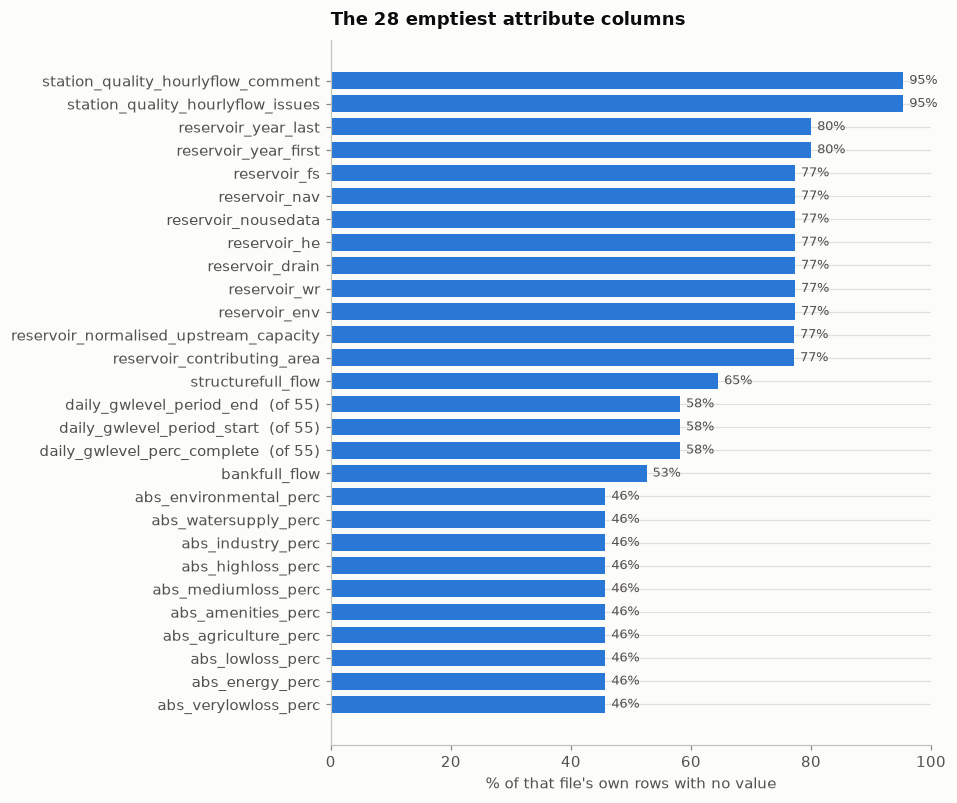

In [24]:
miss = []
for n in ATTR_FILES:
    d = frames[n]
    for c in d.columns:
        pct = d[c].isna().mean() * 100
        if pct > 0:
            miss.append({"file": n, "column": c, "pct": pct})
miss = pd.DataFrame(miss).sort_values("pct", ascending=False)
total_cols = sum(frames[n].shape[1] for n in ATTR_FILES)
print(f"{len(miss)} of {total_cols} attribute columns contain any NaN")
print(miss.groupby("file")["column"].count().sort_values(ascending=False).to_string())

# groundwaterwell has 55 rows, not 671 -- label those so one shared axis does
# not silently imply a common denominator.
miss["rows"] = miss["file"].map({n: len(frames[n]) for n in ATTR_FILES})
miss["label"] = np.where(miss["rows"] == 671, miss["column"],
                         miss["column"] + "  (of " + miss["rows"].astype(str) + ")")

fig, ax = plt.subplots(figsize=(8.8, 7.4))
top_missing = miss.head(28).iloc[::-1]
ax.barh(top_missing["label"], top_missing["pct"], color=SERIES[0], height=0.72)
for y, (_, r) in enumerate(top_missing.iterrows()):
    ax.text(r["pct"] + 1, y, f"{r['pct']:.0f}%", va="center", color=INK_2, fontsize=8.5)
ax.set_xlim(0, 100)
ax.set_xlabel("% of that file's own rows with no value")
ax.set_title("The 28 emptiest attribute columns")
ax.grid(axis="x")
plt.tight_layout()
plt.show()

## 14. The gotcha list

Everything on this list is demonstrated somewhere above.

| # | Gotcha | Where |
|---|---|---|
| 1 | `discharge_spec` is **mm/day** in daily files, **mm/hour** in hourly ones | §11 |
| 2 | `camels_gb_v2_hydrometry_attributes.csv` breaks the default CSV parser — 2 unquoted commas, no quoting in the file | §8 |
| 3 | `gauge_lat`/`gauge_lon` are rounded to 2 dp (~1 km); eastings are exact | §12 |
| 4 | Hourly CEH-GEAR ends 2016, not the documented 2019 | §12 |
| 5 | Hourly precipitation columns cover only part of their own file; GRaD-GB starts 2006 | §11 |
| 6 | NaN ≠ 0 in human influence — NaN is "not surveyed" (England-only product) | §9 |
| 7 | Land cover years are 1990, 2015, 2017–2022 — a 25-year gap, and no 2016 | §6 |
| 8 | Two baseflow indices, two precipitation products, four PET variants — alternatives, not components | §4, §11 |
| 9 | `station_type` combines two codes on one station; 42 strings from 16 base codes | §8 |
| 10 | `high_prec_timing` is NaN when two seasons tie — by design, not a gap | §3 |
| 11 | Soil columns follow `<attr>` / `_missing` / `_5` / `_50` / `_95`; the four composition attributes have no percentiles | §7 |
| 12 | The supporting document says 56 monthly groundwater files; there are 55 | below |

In [25]:
n_monthly = len(list((GW / "monthly").glob("*.csv")))
print(f"monthly groundwater files on disk: {n_monthly}")
print(f"wells in the attribute table:      {len(wells)}")
print(f"supporting document states:        56")
print("\nThe attribute table and the files agree with each other; the document does not.")

monthly groundwater files on disk: 55
wells in the attribute table:      55
supporting document states:        56

The attribute table and the files agree with each other; the document does not.


## 15. Export

A single flat table joining every documented field to its measured profile,
written to `reference/camels_gb_v2_field_profile.csv` for use outside this notebook.

In [26]:
profile_rows = []
for n in ATTR_FILES:
    t = fields(frames[n], n); t.insert(0, "scope", n); profile_rows.append(t)
for scope, ex in [("timeseries_daily", daily_ex), ("timeseries_hourly", hourly_ex),
                  ("timeseries_gw", gw_ex)]:
    t = fields(ex, scope); t.insert(0, "scope", scope); profile_rows.append(t)

profile = pd.concat(profile_rows, ignore_index=True)
profile = profile.merge(DICT[["scope", "column", "group", "source"]],
                        on=["scope", "column"], how="left")
out = ROOT / "reference" / "camels_gb_v2_field_profile.csv"
profile.to_csv(out, index=False)
print(f"wrote {out.relative_to(ROOT)}: {len(profile)} rows x {profile.shape[1]} cols")
print(f"undocumented fields: {int((profile['description'] == 'NOT DOCUMENTED').sum())}")
profile.head(8)

wrote reference/camels_gb_v2_field_profile.csv: 263 rows x 9 cols
undocumented fields: 0


,scope,column,dtype,missing,values,unit,description,group,source
0,topographic,gauge_id,int64,—,"1,001 … 1.07e+05 (whole numbers)",-,catchment identifier (corresponds to the gaugi...,Location and Topography,UK National River Flow Archive using the NRFA ...
1,topographic,gauge_name,str,—,Ugie at Inverugie · Ythan at Ellon · Wick ...,-,gauge name (river name followed by gauging sta...,Location and Topography,UK National River Flow Archive using the NRFA ...
2,topographic,gauge_lat,float64,—,50.16 … 59.11,°,gauge latitude,Location and Topography,UK National River Flow Archive using the NRFA ...
3,topographic,gauge_lon,float64,—,-6.42 … 1.46,°,gauge longitude,Location and Topography,UK National River Flow Archive using the NRFA ...
4,topographic,gauge_easting,int64,—,1.402e+05 … 6.36e+05 (whole numbers),m,gauge easting,Location and Topography,UK National River Flow Archive using the NRFA ...
5,topographic,gauge_northing,int64,—,3.417e+04 … 1.025e+06 (whole numbers),m,gauge northing,Location and Topography,UK National River Flow Archive using the NRFA ...
6,topographic,gauge_elev,float64,—,1.5 … 533,m.a.s.l,gauge elevation,Location and Topography,UK National River Flow Archive using the NRFA ...
7,topographic,area,float64,—,"1.63 … 9,931",km2,catchment area,Location and Topography,CEH's Integrated Hydrological Digital Terrain ...
